# A 2.7-bit element format for Arm CPUs

We explore a highly compressed element format for efficient decoding to INT8 on Arm CPUs. It stores 3 values in an 8-bit pack, which can be decoded using a small number of SIMD instructions.

The data layout and processing is as follows:

<img src="data/format3v8.png" width="800px">

The lookup combines a per-value "sign" index bit with a shared "abs" 5-bit index to form a 6-bit index into a lookup table (a separate lookup table for each of the 3 values), which returns the decoded INT8 value directly.

---

**Construction**

This is a vector format that represents the absolute values of 3 components using a lookup table of 32 entries (5 bits), and a sign bit for each component. To build the format, we pad and rearrange a tensor into 3-vectors and run k-means on the absolute values to build the centroids. Then we quantize each value to the nearest centroid and store the index and sign bit.

Note that this format is a highly quantised element format, designed to be wrapped in a block or channel scaling format.

---

**Decoding**

This format is designed to make full use of Arm's table lookup instruction `TBL`, which maps 16x 6-bit indices to 1-byte outputs in a single instruction. We encode signs in the index, as this can be faster than doing additional arithmetic to extract and apply signs after the lookup. Using the specialised layout above, we can keep 2/3 indices contiguous (putting one sign bit before the shared index, and one sign bit after). The final sign bit can be applied on top of the first index, saving one instruction by relying on a right-shift of 7 bits to zero out the rest of the sign mask.

For example, here is the inner loop of a fused matrix-vector product, slightly rearranged and annotated. We decode 3x16 values in 8 instructions: 5 arithmetic instructions to construct indices and 3 `TBL` instructions to decode the values.

```s
.LBB184_5:
	ldr	q26, [x2, x1]                           // Loading/looping
	ldr	q25, [x15, x1]
	add	x1, x1, #16
	cmp	x12, w1, uxtw

	and	v27.16b, v26.16b, v5.16b                // Format decoding
	ushr	v28.16b, v26.16b, #1
	and	v28.16b, v28.16b, v5.16b
	ushr	v26.16b, v26.16b, #7
	eor	v26.16b, v27.16b, v26.16b
	tbl	v29.16b, { v1.16b, v2.16b, v3.16b, v4.16b }, v27.16b
	tbl	v28.16b, { v16.16b, v17.16b, v18.16b, v19.16b }, v28.16b
	tbl	v26.16b, { v20.16b, v21.16b, v22.16b, v23.16b }, v26.16b

	sdot	v24.4s, v25.16b, v29.16b                // Dot product
	sdot	v7.4s, v25.16b, v28.16b
	sdot	v6.4s, v25.16b, v26.16b

	b.hi	.LBB184_5
```

## Format construction example

In [46]:
import torch
from torch import Tensor


def k_means(t: Tensor, n_centroids: int, threshold: float) -> Tensor:
    _, dim = t.shape
    t = t.float()
    centroids = t[torch.randperm(t.shape[0], device=t.device)[:n_centroids]].clone()
    idx = torch.zeros(t.shape[0], device=t.device, dtype=torch.int64)
    last_idx = torch.full_like(idx, -1)
    while (last_idx != idx).float().mean().item() > threshold:
        last_idx, idx = idx, torch.cdist(t, centroids).argmin(-1)
        centroids.scatter_reduce_(
            0, idx[:, None].expand(-1, dim), t, "mean", include_self=False
        )
    return centroids


# Generate data
torch.manual_seed(0)
data = torch.randn(2**16, 3)

# Format construction
centroids = k_means(data.abs(), 32, 1e-4)

# Quantisation
q_abs_idx = torch.cdist(data.abs(), centroids).argmin(-1)
q_sign = (data < 0)

# Encoding
code_data = (
    (q_abs_idx << 1)
    | q_sign[:, 0] | (q_sign[:, 1] << 6) | ((q_sign[:, 0] ^ q_sign[:, 2]) << 7)
).byte()
code_tables = torch.stack([
    torch.stack([centroids[:, 0], -centroids[:, 0]], dim=1).view(-1),  # sign-minor
    torch.stack([centroids[:, 1], -centroids[:, 1]], dim=0).view(-1),  # sign-major
    torch.stack([centroids[:, 2], -centroids[:, 2]], dim=1).view(-1),  # sign-minor
])

# Decoding
idx0 = code_data & 0x3f
idx1 = (code_data >> 1) & 0x3f
idx2 = idx0 ^ (code_data >> 7)
decoded = torch.stack([
    code_tables[0][idx0.long()],
    code_tables[1][idx1.long()],
    code_tables[2][idx2.long()],
], dim=1)

# Checks
assert torch.equal(decoded, centroids[q_abs_idx] * (1 - 2 * q_sign.float()))
print("RMSE:", (decoded - data).pow(2).mean().sqrt().item())

RMSE: 0.20928484201431274


## Centroids visualisation

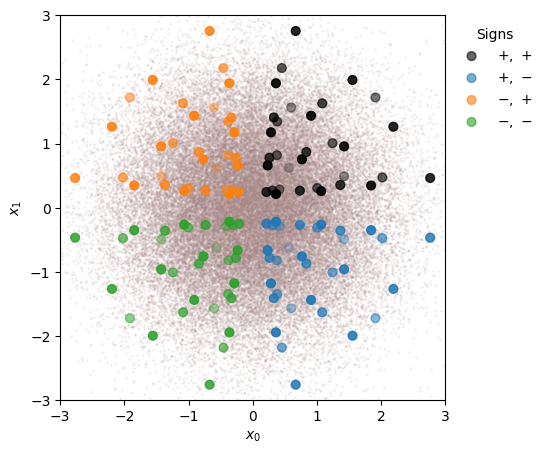

In [47]:
import matplotlib.pyplot as plt
import matplotlib

_, ax = plt.subplots(figsize=(5, 5))
sign_pairs = [[1, 1], [1, -1], [-1, 1], [-1, -1]]
for signs, color in zip(sign_pairs, ["k", *matplotlib.colormaps["tab10"].colors]):
    alpha = (1-0.8*centroids[:, 2].div(centroids[:, 2].max()))
    ax.scatter(
        *centroids[:, :2].mul(torch.tensor(signs)).T,
        alpha=alpha, lw=1, s=40, color=color,
        label=f"${'+' if signs[0] > 0 else '-'} ,\\, {'+' if signs[1] > 0 else '-'}$"
    )
ax.scatter(*data[:, :2].T, alpha=0.1, color="#a88", s=1, zorder=-1)
ax.legend(title="Signs", bbox_to_anchor=(1, 1), loc="upper left", frameon=False)
ax.set_xlim((-3, 3))
ax.set_ylim((-3, 3))
ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")
ax.set_aspect("equal")